# Brauer Impact Factor and Entropy of Brauer Configuration Algebras

## A Computational Companion to the Paper

**Authors:** Carlos Isaac Zainea Maya & Agustín Moreno Cañadas  
**Affiliation:** Departamento de Matemáticas, Universidad Nacional de Colombia, Bogotá

---

This notebook reproduces every computation in the paper *"Brauer Impact Factor and Entropy of Brauer Configuration Algebras: Formalization and Application to Citation Networks"* using the [`aiq-quivers`](https://pypi.org/project/aiq-quivers/) package.

### Table of Contents

1. [Installation](#1-installation)
2. [Preliminaries: Brauer Configurations](#2-preliminaries)
3. [Toy Example: 3 Articles, 5 References (Section 3)](#3-toy-example)
4. [The Brauer Impact Factor $\delta_{\mathcal{B}}$ (Section 4)](#4-impact-factor)
5. [The Brauer Entropy $H(\mathcal{B})$ (Section 5)](#5-entropy)
6. [Relationships with Classical Invariants (Section 6)](#6-relationships)
7. [Verification: Partitions of 10 (Example 5.2)](#7-verification)
8. [Application: The Cañadas Citation Network (Section 7)](#8-application)
9. [Visualization of the Brauer Quiver](#9-visualization)
10. [Open Problems and Extensions](#10-open-problems)

## 1. Installation <a id='1-installation'></a>

In [1]:
!pip install aiq-quivers ipywidgets -q

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import networkx as nx
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown

from aiq import Quiver, BrauerConfiguration, AIQ
from aiq.brauer import (
    brauer_from_citation_json,
    example_partitions_of_10,
    example_compositions_B7,
)
from aiq.datasets import load_canadas_citation_network, example_5node_citation_quiver

# ── Utility: draw a labeled Brauer quiver ──────────────────────────────

def draw_brauer_quiver(bc, pos=None, ax=None, figsize=(10, 7),
                        title=None, show_edge_labels=True,
                        node_size=2200, font_size=12):
    """
    Draws the Brauer quiver Q_M with labeled and colored arrows.
    Each arrow is colored by the reference that generates it and
    labeled with the arrow name (α_ref).
    """
    Q = bc.brauer_quiver()
    G = Q.to_networkx()

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    if pos is None:
        pos = nx.spring_layout(G, seed=42, k=2.5)

    # Assign a color to each reference
    all_refs = list(bc.Gamma0)
    cmap = plt.cm.get_cmap('tab20', max(len(all_refs), 1))
    ref_color = {r: cmap(i) for i, r in enumerate(all_refs)}

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#FDD835',
                           node_size=node_size, edgecolors='black', linewidths=2)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=font_size, font_weight='bold')

    # Group arrows by (src, tgt) to offset multiples
    edge_groups = {}
    for name, src, tgt in Q.Q1:
        key = (src, tgt)
        edge_groups.setdefault(key, []).append(name)

    drawn_labels = {}
    for (src, tgt), names in edge_groups.items():
        n_edges = len(names)
        for idx, name in enumerate(names):
            # Extract reference from arrow name: s_{ref}_{src}_to_{tgt}_{i}
            parts = name.split('_')
            ref = parts[1] if len(parts) > 1 else '?'
            color = ref_color.get(ref, 'gray')

            if src == tgt:  # loop
                rad = 0.3 + idx * 0.15
                style = f'arc3,rad={rad}'
            elif n_edges == 1:
                rad = 0.15
                style = f'arc3,rad={rad}'
            else:
                rad = 0.1 + idx * 0.12
                style = f'arc3,rad={rad}'

            nx.draw_networkx_edges(
                G, pos, edgelist=[(src, tgt)], ax=ax,
                edge_color=[color], width=2, connectionstyle=style,
                arrows=True, arrowstyle='-|>', arrowsize=18,
                min_source_margin=22, min_target_margin=22)

            if show_edge_labels:
                label = f'$\\alpha_{{{ref}}}$'
                # Position the label along the curved edge
                x_s, y_s = pos[src]
                x_t, y_t = pos[tgt]
                frac = 0.45 + idx * 0.05
                lx = x_s + frac * (x_t - x_s) + rad * (y_t - y_s) * 0.3
                ly = y_s + frac * (y_t - y_s) - rad * (x_t - x_s) * 0.3
                ax.text(lx, ly, label, fontsize=7, color=color,
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.7))

    # Legend: one entry per reference with val > 1 or all if small
    legend_refs = [r for r in all_refs if bc.valency(r) >= 2] if len(all_refs) > 10 else all_refs
    handles = [mpatches.Patch(color=ref_color[r], label=f'{r} (val={bc.valency(r)})')
               for r in legend_refs[:12]]
    if len(all_refs) > 12:
        handles.append(mpatches.Patch(color='gray', label=f'... +{len(all_refs)-12} more'))
    ax.legend(handles=handles, loc='upper left', fontsize=8, framealpha=0.9)

    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_axis_off()
    fig.tight_layout()
    return fig, ax

print("✓ Paquete AIQ cargado. Funciones de visualización listas.")

✓ Paquete AIQ cargado. Funciones de visualización listas.


## 2. Preliminaries: Brauer Configurations <a id='2-preliminaries'></a>

A **Brauer configuration** (Green & Schroll, 2017, Def. 1.5) is a quadruple $\Gamma = (\Gamma_0, \Gamma_1, \mu, \mathcal{O})$ satisfying:

| Condition | Statement |
|-----------|-----------|
| **(C1)** | $\Gamma_0$ is a finite set of **vertices**. Every vertex belongs to $\geq 1$ polygon. |
| **(C2)** | $\Gamma_1 = \{M_1, \ldots, M_h\}$ is a finite collection of multisets (**polygons**) over $\Gamma_0$. Every polygon has $\geq 2$ vertices. |
| **(C3)** | $\mu: \Gamma_0 \to \mathbb{N}^+$ is the **multiplicity function**. Every polygon has at least one vertex $m$ with $\text{val}(m) \cdot \mu(m) > 1$. |
| **(C4)** | $\mathcal{O}$ is an **orientation**: cyclic ordering at each vertex. |

**Key definitions:**

- **Valency**: $\text{val}(m) = \sum_{i=1}^{h} f_i(m)$ — total occurrences of $m$ across all polygons
- **Univalent vertex**: $m$ with $\text{val}(m) \cdot \mu(m) = 1$ (i.e., $\text{val}=1$ and $\mu=1$)
- **MNTI multiplicity** (thematic specialization depth):

$$\mu(m) = \begin{cases} 2 & \text{if } \text{val}(m) = 1 \quad \text{(thematic anchor: specialized reference)} \\ 1 & \text{if } \text{val}(m) \geq 2 \quad \text{(shared reference, influence captured by valency)} \end{cases}$$

Under the MNTI $\mu$, every vertex has $\omega(m) = \mu \cdot \text{val} \geq 2$, so all vertices are **multivalent** and **(C3)** is automatically satisfied.

**Classical invariants:**

$$\dim_k \Lambda_{\mathcal{M}} = 2h + \sum_{m \in \Gamma_0} \text{val}(m)(\mu(m) \cdot \text{val}(m) - 1) \quad \text{(Thm. 2.1)}$$

$$\dim_k Z(\Lambda_{\mathcal{M}}) = 1 + \sum_{m} \mu(m) + h - n + \#\text{Loops}(Q_{\mathcal{M}}) - |C_{\mathcal{M}}^*| \quad \text{(Thm. 2.2)}$$

## 3. Toy Example: 3 Articles, 5 References (Section 3) <a id='3-toy-example'></a>

Consider a research group publishing three articles:

| Article | Year | Polygon | References |
|---------|------|---------|------------|
| "Algebra of X" | 2021 | $P_1$ | $\{a, b, c\}$ |
| "Applications of X" | 2022 | $P_2$ | $\{b, c, d\}$ |
| "Extensions of X" | 2023 | $P_3$ | $\{a, c, e\}$ |

### Step 1: Build the Brauer configuration

In [3]:
bc_toy = BrauerConfiguration(
    vertices=['a', 'b', 'c', 'd', 'e'],
    polygons={
        'P1': ['a', 'b', 'c'],
        'P2': ['b', 'c', 'd'],
        'P3': ['a', 'c', 'e'],
    },
    polygon_data={
        'P1': {'year': 2021},
        'P2': {'year': 2022},
        'P3': {'year': 2023},
    },
)

print(f"|Γ₀| = {bc_toy.n_vertices} (references)")
print(f"|Γ₁| = {bc_toy.n_polygons} (articles)")

|Γ₀| = 5 (references)
|Γ₁| = 3 (articles)


### Step 2: Valencies and multiplicities

In [4]:
refs = ['a', 'b', 'c', 'd', 'e']
descriptions = ['foundational', 'methods', 'survey', 'specialized (apps)', 'specialized (ext)']

table = pd.DataFrame({
    'Vértice $m$': refs,
    'Descripción': descriptions,
    '$\\mathrm{val}(m)$': [bc_toy.valency(v) for v in refs],
    '$\\mu(m)$': [bc_toy.mu(v) for v in refs],
    '$\\omega(m) = \\mu \\cdot \\mathrm{val}$': [bc_toy.mu(v) * bc_toy.valency(v) for v in refs],
    'Rol': ['ancla temática' if bc_toy.valency(v) == 1 else 'compartida' for v in refs],
})

_map_fn = getattr(table.style, 'map', None) or table.style.applymap  # compat pandas <2.1 / >=2.1
table.style\
    .set_caption("Tabla 1: Valencias, multiplicidades y pesos — multiplicidad estándar")\
    .hide(axis='index')\
    .set_properties(**{'text-align': 'center'})\
    .set_properties(subset=['Descripción'], **{'text-align': 'left'})

Vértice $m$,Descripción,$\mathrm{val}(m)$,$\mu(m)$,$\omega(m) = \mu \cdot \mathrm{val}$,Rol
a,foundational,2,1,2,compartida
b,methods,2,1,2,compartida
c,survey,3,1,3,compartida
d,specialized (apps),1,2,2,ancla temática
e,specialized (ext),1,2,2,ancla temática


**Interpretation of the table:**

- References $a, b, c$ have $\text{val} \geq 2$ — they are **shared** across multiple articles → $\mu = 1$ (their influence is already captured by valency)
- References $d, e$ have $\text{val} = 1$ — they are **specialized**, cited by a single article → $\mu = 2$ (**thematic anchor** weight: recognizes depth, not frequency)
- Under the standard $\mu$, **no vertex is truncated** ($\omega \geq 2$ for all), so condition **(C3)** holds automatically

### Step 3: Successor sequences

For each reference $m$, the orientation $\mathcal{O}$ (chronological order) induces a cyclic ordering of the polygons containing $m$. This generates the **successor sequence** $S_m$.

In [5]:
seqs = bc_toy.successor_sequences()

for v in refs:
    seq = seqs[v]
    val = bc_toy.valency(v)
    vtype = "univalent" if bc_toy.valency(v) == 1 else "multivalent"
    seq_str = ' < '.join(f'{p}^({c})' for p, c in seq)
    print(f"  S_{v} (val={val}, {vtype}): {seq_str}")
    
    # Show the arrows generated
    for i in range(len(seq)):
        src = seq[i][0]
        tgt = seq[(i + 1) % len(seq)][0]
        arrow_type = "loop" if src == tgt else "arrow"
        print(f"    → {src} → {tgt}  ({arrow_type})")
    print()

  S_a (val=2, multivalent): P1^(1) < P3^(1)
    → P1 → P3  (arrow)
    → P3 → P1  (arrow)

  S_b (val=2, multivalent): P1^(1) < P2^(1)
    → P1 → P2  (arrow)
    → P2 → P1  (arrow)

  S_c (val=3, multivalent): P1^(1) < P2^(1) < P3^(1)
    → P1 → P2  (arrow)
    → P2 → P3  (arrow)
    → P3 → P1  (arrow)

  S_d (val=1, univalent): P2^(1)
    → P2 → P2  (loop)

  S_e (val=1, univalent): P3^(1)
    → P3 → P3  (loop)



### Step 4: The Brauer quiver $Q_{\mathcal{M}}$

The Brauer quiver has:
- **Vertices** $(Q_{\mathcal{M}})_0 = \Gamma_1$ (one vertex per polygon/article)
- **Arrows**: one per consecutive pair in each successor sequence

In [6]:
Q_toy = bc_toy.brauer_quiver()

print(f"Brauer quiver Q_M:")
print(f"  Vertices: {Q_toy.Q0}")
print(f"  |Q₁| = {Q_toy.n_arrows} arrows")
print(f"  #Loops = {bc_toy.n_loops()}")
print()

# Classify arrows
loops = []
non_loops = []
for name, src, tgt in Q_toy.Q1:
    if src == tgt:
        loops.append((name, src))
    else:
        non_loops.append((name, src, tgt))

print(f"  Non-loop arrows ({len(non_loops)}):")
for name, s, t in non_loops:
    print(f"    {s} → {t}")
print(f"  Loops ({len(loops)}):")
for name, s in loops:
    print(f"    {s} ↺")

Brauer quiver Q_M:
  Vertices: ['P1', 'P2', 'P3']
  |Q₁| = 9 arrows
  #Loops = 2

  Non-loop arrows (7):
    P1 → P3
    P3 → P1
    P1 → P2
    P2 → P1
    P1 → P2
    P2 → P3
    P3 → P1
  Loops (2):
    P2 ↺
    P3 ↺


### Step 5: Visualize the Brauer quiver

/tmp/ipykernel_108851/1103043942.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(len(all_refs), 1))


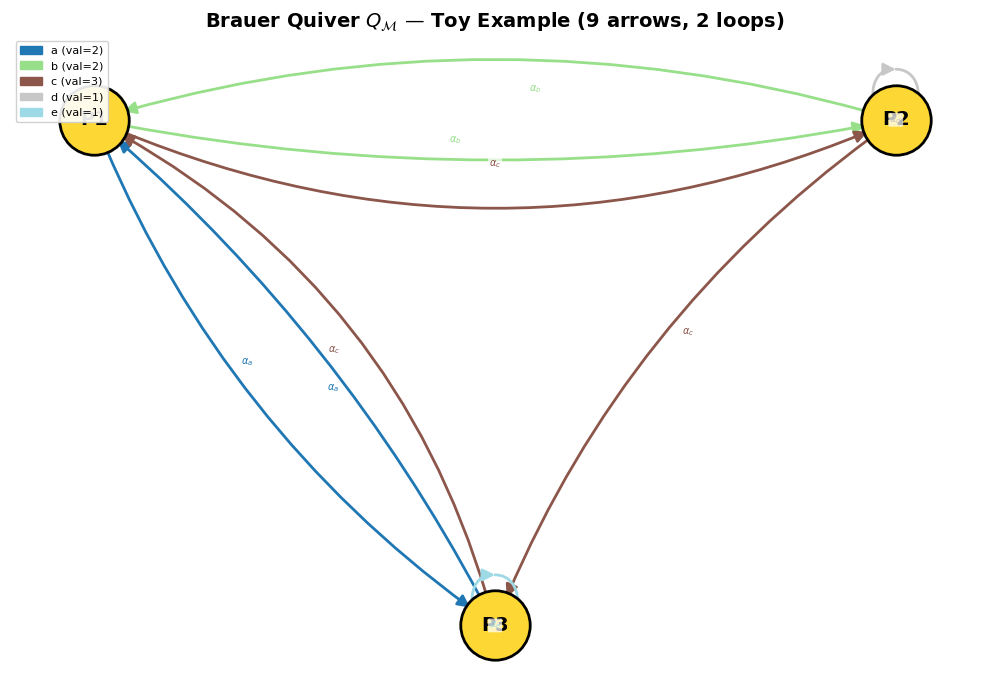

In [7]:
pos_toy = {'P1': (-1, 0), 'P2': (1, 0), 'P3': (0, -1.5)}

draw_brauer_quiver(
    bc_toy, pos=pos_toy, figsize=(10, 7),
    title=f'Brauer Quiver $Q_{{\\mathcal{{M}}}}$ — Toy Example ({Q_toy.n_arrows} arrows, {bc_toy.n_loops()} loops)',
    show_edge_labels=True,
    node_size=2500, font_size=14,
)
plt.show()

### Step 6: Classical invariants

In [8]:
analysis = bc_toy.brauer_analysis()

S = sum(bc_toy.valency(v) for v in refs)
n = bc_toy.n_vertices
h = bc_toy.n_polygons

print("Classical invariants (Section 3, Step 5):")
print(f"  S = Σval(m) = {S}  (total incidences = number of arrows)")
print(f"  #Loops = {analysis['n_loops']}")
print(f"  dim_k Λ_M = {analysis['dimension']}")
print(f"  dim_k Z(Λ_M) = {analysis['center_dimension']}")
print()

# Manual verification of dimension formula
dim_manual = 2 * h
for v in refs:
    val = bc_toy.valency(v)
    mu = bc_toy.mu(v)
    contrib = val * (mu * val - 1)
    dim_manual += contrib
    print(f"  val({v})·(μ({v})·val({v}) - 1) = {val}·({mu}·{val} - 1) = {contrib}")
print(f"  dim = 2·{h} + {dim_manual - 2*h} = {dim_manual}  ✓")

Classical invariants (Section 3, Step 5):
  S = Σval(m) = 9  (total incidences = number of arrows)
  #Loops = 2
  dim_k Λ_M = 18
  dim_k Z(Λ_M) = 6

  val(a)·(μ(a)·val(a) - 1) = 2·(1·2 - 1) = 2
  val(b)·(μ(b)·val(b) - 1) = 2·(1·2 - 1) = 2
  val(c)·(μ(c)·val(c) - 1) = 3·(1·3 - 1) = 6
  val(d)·(μ(d)·val(d) - 1) = 1·(2·1 - 1) = 1
  val(e)·(μ(e)·val(e) - 1) = 1·(2·1 - 1) = 1
  dim = 2·3 + 12 = 18  ✓


### Explorador interactivo: construya su propia configuración de Brauer

Use los controles para definir polígonos (artículos) y vértices (referencias). El sistema calcula automáticamente todos los invariantes y dibuja el quiver $Q_{\mathcal{M}}$ con flechas etiquetadas.

In [9]:
# ══════════════════════════════════════════════════════════════════
# INTERACTIVE WIDGET: Build your own Brauer configuration
# ══════════════════════════════════════════════════════════════════

style = {'description_width': '140px'}
layout = widgets.Layout(width='95%')

intro_html = widgets.HTML(
    "<h4>Defina los polígonos como listas de vértices separados por comas.</h4>"
    "<p>Ejemplo: <code>a, b, c</code> significa que el polígono contiene las referencias a, b, c.</p>"
)

p1_input = widgets.Text(value='a, b, c', description='Polígono P₁:', style=style, layout=layout)
p2_input = widgets.Text(value='b, c, d', description='Polígono P₂:', style=style, layout=layout)
p3_input = widgets.Text(value='a, c, e', description='Polígono P₃:', style=style, layout=layout)
p4_input = widgets.Text(value='', description='Polígono P₄ (opcional):', style=style, layout=layout,
                        placeholder='Dejar vacío si no se usa')

show_labels_check = widgets.Checkbox(value=True, description='Mostrar etiquetas en aristas',
                                      style=style)
run_button = widgets.Button(description='Calcular invariantes y dibujar',
                            button_style='success', icon='calculator',
                            layout=widgets.Layout(width='300px', height='40px'))
output_area = widgets.Output()

def on_run_clicked(b):
    output_area.clear_output(wait=True)
    with output_area:
        try:
            # Parse polygons
            polygons = {}
            all_verts = set()
            for i, inp in enumerate([p1_input, p2_input, p3_input, p4_input], 1):
                text = inp.value.strip()
                if not text:
                    continue
                refs = [r.strip() for r in text.split(',') if r.strip()]
                if refs:
                    polygons[f'P{i}'] = refs
                    all_verts.update(refs)

            if len(polygons) < 1:
                print("⚠ Defina al menos un polígono.")
                return

            vertices = sorted(all_verts)
            bc = BrauerConfiguration(vertices=vertices, polygons=polygons)

            # ── Table of invariants ──
            display(Markdown("### Resultados"))

            # Per-vertex table
            rows = []
            for v in vertices:
                rows.append({
                    'Vértice m': v,
                    'val(m)': bc.valency(v),
                    'μ(m)': bc.mu(v),
                    'ω(m) = μ·val': bc.mu(v) * bc.valency(v),
                    'Truncado': '✓' if bc.is_truncated(v) else '',
                })
            display(pd.DataFrame(rows).style.set_caption("Tabla de vértices"))

            # Global invariants
            delta = bc.impact_factor()
            H = bc.entropy()
            n = bc.n_vertices
            h = bc.n_polygons
            C_M = sum(1 for v in vertices if bc.is_truncated(v))
            S = sum(bc.valency(v) for v in vertices)

            inv = pd.DataFrame([
                {'Invariante': '|Γ₀| (vértices)', 'Valor': n},
                {'Invariante': '|Γ₁| (polígonos)', 'Valor': h},
                {'Invariante': 'S = Σval(m) = |Q₁|', 'Valor': S},
                {'Invariante': '|C_M| (truncados)', 'Valor': C_M},
                {'Invariante': '#Loops(Q_M)', 'Valor': bc.n_loops()},
                {'Invariante': 'dim_k Λ_M', 'Valor': bc.dimension()},
                {'Invariante': 'dim_k Z(Λ_M)', 'Valor': bc.center_dimension()},
                {'Invariante': 'δ_B (impact factor)', 'Valor': delta},
                {'Invariante': 'H(B) (entropía, bits)', 'Valor': f'{H:.4f}'},
                {'Invariante': 'ρ(B) = H/log₂(n)', 'Valor': f'{H / math.log2(n):.4f}' if n > 1 else 'N/A'},
            ])
            display(inv.style.set_caption("Invariantes de Brauer").hide(axis='index'))

            # ── Draw quiver ──
            display(Markdown("### Quiver de Brauer $Q_{\\mathcal{M}}$"))
            draw_brauer_quiver(
                bc, figsize=(9, 6),
                title=f'$Q_{{\\mathcal{{M}}}}$: {Q_arrows} flechas, {bc.n_loops()} loops'
                      if (Q_arrows := bc.brauer_quiver().n_arrows) else '',
                show_edge_labels=show_labels_check.value,
            )
            plt.show()

            # ── Successor sequences ──
            display(Markdown("### Secuencias de sucesores"))
            seqs = bc.successor_sequences()
            for v in vertices:
                seq = seqs[v]
                seq_str = ' → '.join(f'{p}' for p, c in seq)
                trunc = " (truncado → loop)" if bc.is_truncated(v) else ""
                print(f"  S_{v}: {seq_str} ↻{trunc}")

        except Exception as e:
            print(f"❌ Error: {e}")

run_button.on_click(on_run_clicked)

display(intro_html,
        p1_input, p2_input, p3_input, p4_input,
        show_labels_check, run_button, output_area)

HTML(value='<h4>Defina los polígonos como listas de vértices separados por comas.</h4><p>Ejemplo: <code>a, b, …

Text(value='a, b, c', description='Polígono P₁:', layout=Layout(width='95%'), style=TextStyle(description_widt…

Text(value='b, c, d', description='Polígono P₂:', layout=Layout(width='95%'), style=TextStyle(description_widt…

Text(value='a, c, e', description='Polígono P₃:', layout=Layout(width='95%'), style=TextStyle(description_widt…

Text(value='', description='Polígono P₄ (opcional):', layout=Layout(width='95%'), placeholder='Dejar vacío si …

Checkbox(value=True, description='Mostrar etiquetas en aristas', style=CheckboxStyle(description_width='140px'…

Button(button_style='success', description='Calcular invariantes y dibujar', icon='calculator', layout=Layout(…

Output()

## 4. The Brauer Impact Factor $\delta_{\mathcal{B}}$ (Section 4) <a id='4-impact-factor'></a>

### Definition 4.1

The **vertex weight** is $\omega(m) = \mu(m) \cdot \text{val}(m)$ and the **Brauer impact factor** is:

$$\delta_{\mathcal{B}} = \sum_{m \in \Gamma_0} \omega(m) = \sum_{m \in \Gamma_0} \mu(m) \cdot \text{val}(m)$$

### Theorem 4.1 — Univalent-Core Decomposition

$$\delta_{\mathcal{B}} = \delta_{\mathcal{B}}^{\text{univ}} + \delta_{\mathcal{B}}^{\text{core}}$$

With MNTI multiplicity: $\delta_{\mathcal{B}} = 2|C_{\mathcal{M}}| + \sum_{m \notin C_{\mathcal{M}}} \text{val}(m) = S + |C_{\mathcal{M}}|$

In [10]:
delta = bc_toy.impact_factor()
# C_M = vertices with val=1 (thematic anchors under standard μ)
C_M = [v for v in refs if bc_toy.valency(v) == 1]
delta_univ = sum(bc_toy.mu(v) * bc_toy.valency(v) for v in C_M)
delta_core = delta - delta_univ

print(f"Impact factor: δ_B = {delta}")
print(f"  δ_B^univ = {delta_univ}  ({100*delta_univ/delta:.1f}%) — thematic anchors (val=1, μ=2)")
print(f"  δ_B^core  = {delta_core}  ({100*delta_core/delta:.1f}%) — shared references (val≥2, μ=1)")
print()
print(f"Formula check: S + |C_M| = {S} + {len(C_M)} = {S + len(C_M)}  (= δ_B = {delta})  ✓")

Impact factor: δ_B = 11
  δ_B^univ = 4  (36.4%) — thematic anchors (val=1, μ=2)
  δ_B^core  = 7  (63.6%) — shared references (val≥2, μ=1)

Formula check: S + |C_M| = 9 + 2 = 11  (= δ_B = 11)  ✓


### Proposition 4.2 — Bounds on $\delta_{\mathcal{B}}$

- **Lower bound:** $\delta_{\mathcal{B}} \geq 2n$ (equality iff all vertices univalent)
- **Sharp formula:** $\delta_{\mathcal{B}} = S + |C_{\mathcal{M}}|$

In [11]:
print(f"Lower bound: 2n = {2*n}")
print(f"Actual:      δ_B = {delta}")
print(f"δ_B ≥ 2n?    {delta >= 2*n}  ✓")

Lower bound: 2n = 10
Actual:      δ_B = 11
δ_B ≥ 2n?    True  ✓


### Proposition 4.3 — Number of arrows

$|(Q_{\mathcal{M}})_1| = \sum_{m \in \Gamma_0} \text{val}(m) = S$

The multiplicity $\mu$ does **not** affect the number of arrows — it only enters the relations $I$.

In [12]:
print(f"|Q₁| = {Q_toy.n_arrows}")
print(f"S = Σval(m) = {S}")
print(f"Equal? {Q_toy.n_arrows == S}  ✓")
print()
print(f"δ_B - S = {delta - S} = |C_M| = {len(C_M)}  (extra weight from multiplicity)")

|Q₁| = 9
S = Σval(m) = 9
Equal? True  ✓

δ_B - S = 2 = |C_M| = 2  (extra weight from multiplicity)


### Proposition 4.4 — Loops in citation networks

When $f_i(m) \leq 1$ (no repeated refs): $\#\text{Loops}(Q_{\mathcal{M}}) = |C_{\mathcal{M}}|$

In [13]:
print(f"#Loops = {bc_toy.n_loops()}")
print(f"|C_M| (val=1 vertices) = {len(C_M)}")
print(f"Equal? {bc_toy.n_loops() == len(C_M)}  ✓  (Prop. 4.4, citation networks)")
print(f"Thematic anchors generating loops: {C_M}")
print()
print("Note: under standard μ, these are NOT truncated (val·μ = 1·2 = 2 > 1)")
print("but they still generate loops because val=1 → the successor sequence")
print("has only one polygon, so Suc(M^(1)) = M^(1) (self-loop).")

#Loops = 2
|C_M| (val=1 vertices) = 2
Equal? True  ✓  (Prop. 4.4, citation networks)
Thematic anchors generating loops: ['d', 'e']

Note: under standard μ, these are NOT truncated (val·μ = 1·2 = 2 > 1)
but they still generate loops because val=1 → the successor sequence
has only one polygon, so Suc(M^(1)) = M^(1) (self-loop).


## 5. The Brauer Entropy $H(\mathcal{B})$ (Section 5) <a id='5-entropy'></a>

### Definition 5.1 — Weight distribution

$$p_m = \frac{\omega(m)}{\delta_{\mathcal{B}}} = \frac{\mu(m) \cdot \text{val}(m)}{\delta_{\mathcal{B}}}$$

### Definition 5.2 — Brauer entropy

$$H(\mathcal{B}) = -\sum_{m \in \Gamma_0} p_m \log_2 p_m$$

In [14]:
H = bc_toy.entropy()
H_max = math.log2(n)
rho = H / H_max

print("Weight distribution:")
for v in refs:
    w = bc_toy.mu(v) * bc_toy.valency(v)
    p = w / delta
    contrib = -p * math.log2(p)
    print(f"  p_{v} = ω({v})/δ_B = {w}/{delta} = {p:.4f}   → -p·log₂(p) = {contrib:.4f}")

print(f"\nH(B) = {H:.4f} bits")
print(f"H_max = log₂({n}) = {H_max:.4f} bits")
print(f"ρ(B) = H/H_max = {rho:.4f}")
print(f"\nInterpretation: ρ ≈ {rho:.2f} → nearly uniform weight distribution")

Weight distribution:
  p_a = ω(a)/δ_B = 2/11 = 0.1818   → -p·log₂(p) = 0.4472
  p_b = ω(b)/δ_B = 2/11 = 0.1818   → -p·log₂(p) = 0.4472
  p_c = ω(c)/δ_B = 3/11 = 0.2727   → -p·log₂(p) = 0.5112
  p_d = ω(d)/δ_B = 2/11 = 0.1818   → -p·log₂(p) = 0.4472
  p_e = ω(e)/δ_B = 2/11 = 0.1818   → -p·log₂(p) = 0.4472

H(B) = 2.2999 bits
H_max = log₂(5) = 2.3219 bits
ρ(B) = H/H_max = 0.9905

Interpretation: ρ ≈ 0.99 → nearly uniform weight distribution


### Theorem 5.1 — Bounds on entropy

$$0 < H(\mathcal{B}) \leq \log_2 n$$

- Upper bound = $\log_2 n$ iff all weights equal
- Tighter lower bound: $H(\mathcal{B}) \geq \log_2(\delta_{\mathcal{B}}^2 / \sum \omega(m)^2)$

In [15]:
sum_w2 = sum((bc_toy.mu(v) * bc_toy.valency(v))**2 for v in refs)
H_lower_tight = math.log2(delta**2 / sum_w2)

print(f"0 < H(B) = {H:.4f} ≤ log₂(n) = {H_max:.4f}  ✓")
print(f"Tight lower bound: log₂(δ²/Σω²) = log₂({delta}²/{sum_w2}) = {H_lower_tight:.4f}")
print(f"H_lower ≤ H(B)? {H_lower_tight <= H + 1e-10}  ✓")

0 < H(B) = 2.2999 ≤ log₂(n) = 2.3219  ✓
Tight lower bound: log₂(δ²/Σω²) = log₂(11²/25) = 2.2750
H_lower ≤ H(B)? True  ✓


## 6. Relationships with Classical Invariants (Section 6) <a id='6-relationships'></a>

### Theorem 6.1 — Dimension via quadratic weight

$$\dim_k \Lambda_{\mathcal{M}} = 2h + \mathcal{Q}(\Gamma) - S \qquad \text{where } \mathcal{Q}(\Gamma) = \sum_{m} \mu(m) \cdot \text{val}(m)^2$$

### Proposition 6.2 — Center dimension for citation networks

$$\dim_k Z(\Lambda_{\mathcal{M}}) = 1 + h + |C_{\mathcal{M}}|$$

In [16]:
# Quadratic weight Q(Γ)
Q_gamma = sum(bc_toy.mu(v) * bc_toy.valency(v)**2 for v in refs)

dim_via_Q = 2 * h + Q_gamma - S
print(f"Theorem 6.1:")
print(f"  Q(Γ) = Σ μ(m)·val(m)² = {Q_gamma}")
print(f"  dim = 2h + Q - S = 2·{h} + {Q_gamma} - {S} = {dim_via_Q}")
print(f"  Matches dim_k Λ_M = {analysis['dimension']}?  {dim_via_Q == analysis['dimension']}  ✓")
print()

# Center dimension for citation networks
center_citation = 1 + h + len(C_M)
print(f"Proposition 6.2 (citation networks):")
print(f"  dim_k Z = 1 + h + |C_M| = 1 + {h} + {len(C_M)} = {center_citation}")
print(f"  Matches computed = {analysis['center_dimension']}?  {center_citation == analysis['center_dimension']}  ✓")
print()

# Cauchy-Schwarz relationship
w_max = max(bc_toy.mu(v) * bc_toy.valency(v) for v in refs)
CS_lower = delta**2 / n
CS_upper = delta * w_max
print(f"Cauchy-Schwarz (Remark 6.1):")
print(f"  δ²/n = {delta}²/{n} = {CS_lower:.1f} ≤ Q(Γ) = {Q_gamma} ≤ δ·ω_max = {delta}·{w_max} = {CS_upper}  ✓")

Theorem 6.1:
  Q(Γ) = Σ μ(m)·val(m)² = 21
  dim = 2h + Q - S = 2·3 + 21 - 9 = 18
  Matches dim_k Λ_M = 18?  True  ✓

Proposition 6.2 (citation networks):
  dim_k Z = 1 + h + |C_M| = 1 + 3 + 2 = 6
  Matches computed = 6?  True  ✓

Cauchy-Schwarz (Remark 6.1):
  δ²/n = 11²/5 = 24.2 ≤ Q(Γ) = 21 ≤ δ·ω_max = 11·3 = 33  ✓


## 7. Verification: Partitions of 10 (Example 5.2) <a id='7-verification'></a>

From the paper on branched coverings (Cañadas et al., 2024):

$\Gamma_0 = \{1, 2, 3, 4\}$, with polygons:
- $L_1 = (4^2, 2)$ — partition part $[4, 4, 2]$
- $L_2 = (3^3, 1)$ — partition part $[3, 3, 3, 1]$  
- $L_3 = (2^5)$ — partition part $[2, 2, 2, 2, 2]$

**Key difference from citation networks:** Here $f_i(m) > 1$ (e.g., vertex 2 appears 5 times in $L_3$), so multivalent vertices can also generate loops.

In [17]:
bc_p10 = example_partitions_of_10()

verts = [1, 2, 3, 4]

display(Markdown("**Polygons:** $L_1 = (4^2, 2)$, $L_2 = (3^3, 1)$, $L_3 = (2^5)$"))

table_p10 = pd.DataFrame({
    '$m$': verts,
    '$\\mathrm{val}(m)$': [bc_p10.valency(v) for v in verts],
    '$\\mu(m)$': [bc_p10.mu(v) for v in verts],
    '$\\omega(m)$': [bc_p10.mu(v) * bc_p10.valency(v) for v in verts],
    'val=1?': ['✓' if bc_p10.valency(v) == 1 else '' for v in verts],
    'truncated?': ['✓' if bc_p10.is_truncated(v) else '' for v in verts],
})
display(table_p10.style.set_caption("Partitions of 10 — vertices and weights").hide(axis='index')
        .set_properties(**{'text-align': 'center'}))

print("Note: vertex 1 has val=1 but μ=2, so val·μ = 2 > 1 → NOT truncated (standard μ).")
print()

delta_p10 = bc_p10.impact_factor()
H_p10 = bc_p10.entropy()
rho_p10 = H_p10 / math.log2(4)

results = {
    'δ_B': (delta_p10, 13),
    'H(B) bits': (round(H_p10, 4), 1.8339),
    'ρ(B)': (round(rho_p10, 4), 0.9170),
    'dim_k Λ_M': (bc_p10.dimension(), 45),
    'dim_k Z(Λ_M)': (bc_p10.center_dimension(), 14),
    '#Loops': (bc_p10.n_loops(), 10),
}

verify_df = pd.DataFrame([
    {'Invariant': name, 'Computed': computed, 'Paper': expected,
     '': '✓' if computed == expected else '✗'}
    for name, (computed, expected) in results.items()
])
display(verify_df.style.set_caption("Verification against Cañadas et al. (2024), Example 5")
        .hide(axis='index').set_properties(**{'text-align': 'center'}))

/home/isaac-zainea/Dropbox/Documentos/Doctorado Matemáticas/quivers_analysis/aiq/brauer.py:778: UserWarning: C2 violation: polygon 'L3' has only 1 distinct vertex(es).
  return BrauerConfiguration(vertices, polygons, mu=mu)


**Polygons:** $L_1 = (4^2, 2)$, $L_2 = (3^3, 1)$, $L_3 = (2^5)$

$m$,$\mathrm{val}(m)$,$\mu(m)$,$\omega(m)$,val=1?,truncated?
1,1,2,2,✓,
2,6,1,6,,
3,3,1,3,,
4,2,1,2,,


Note: vertex 1 has val=1 but μ=2, so val·μ = 2 > 1 → NOT truncated (standard μ).



Invariant,Computed,Paper,
δ_B,13.000000,13.000000,✓
H(B) bits,1.833900,1.833900,✓
ρ(B),0.917000,0.917000,✓
dim_k Λ_M,45.000000,45.000000,✓
dim_k Z(Λ_M),14.000000,14.000000,✓
#Loops,10.000000,10.000000,✓


**Note on loops:** Here $\#\text{Loops} = 10 \gg |C_{\mathcal{M}}| = 1$. This is because vertex 2 appears 5 times in $L_3$ ($f_3(2) = 5$), generating 4 internal loops at $L_3$. Proposition 4.4 ($\#\text{Loops} = |C_{\mathcal{M}}|$) only holds for citation networks where $f_i(m) \leq 1$.

## 8. Application: The Cañadas Citation Network (Section 7) <a id='8-application'></a>

17 articles by Cañadas et al. (2021–2025) citing 104 distinct references.

In [18]:
bc_canadas, raw_data = load_canadas_citation_network()

n_c = bc_canadas.n_vertices
h_c = bc_canadas.n_polygons
S_c = sum(bc_canadas.valency(v) for v in bc_canadas.Gamma0)
# C_M: val=1 vertices (thematic anchors)
C_M_c = [v for v in bc_canadas.Gamma0 if bc_canadas.valency(v) == 1]

print(f"Cañadas Citation Network:")
print(f"  |Γ₀| = n = {n_c} references")
print(f"  |Γ₁| = h = {h_c} articles")
print(f"  S = {S_c} total incidences")
print(f"  Average refs per article: {S_c/h_c:.1f}")
print(f"  Thematic anchors (val=1): {len(C_M_c)}")
print(f"  Shared references (val≥2): {n_c - len(C_M_c)}")

Cañadas Citation Network:
  |Γ₀| = n = 104 references
  |Γ₁| = h = 17 articles
  S = 204 total incidences
  Average refs per article: 12.0
  Thematic anchors (val=1): 85
  Shared references (val≥2): 19


### Theorem 7.1 — All invariants

In [19]:
delta_c = bc_canadas.impact_factor()
delta_univ_c = sum(bc_canadas.mu(v) * bc_canadas.valency(v) for v in C_M_c)
delta_core_c = delta_c - delta_univ_c
H_c = bc_canadas.entropy()
H_max_c = math.log2(n_c)
rho_c = H_c / H_max_c

paper_values = {
    '|Γ₀| = n': (n_c, 104),
    '|Γ₁| = h': (h_c, 17),
    'S (incidences)': (S_c, 204),
    '|C_M| (univalent)': (len(C_M_c), 85),
    'Non-univalent': (n_c - len(C_M_c), 19),
    'dim_k Λ_M': (bc_canadas.dimension(), 1269),
    'dim_k Z(Λ_M)': (bc_canadas.center_dimension(), 103),
    '#Loops': (bc_canadas.n_loops(), 85),
    'ν(D) (defect)': (bc_canadas.defect(), 0),
    'δ_B': (delta_c, 289),
    'δ_B^univ': (delta_univ_c, 170),
    'δ_B^core': (delta_core_c, 119),
    'H(B) bits': (round(H_c, 4), 6.3062),
    'log₂(n) bits': (round(H_max_c, 4), 6.7004),
    'ρ(B)': (round(rho_c, 4), 0.9412),
}

print(f"{'Invariant':<20} {'Computed':>12} {'Paper':>12} {'Match':>6}")
print("=" * 54)
for name, (computed, expected) in paper_values.items():
    match = '✓' if computed == expected else '✗'
    print(f"{name:<20} {str(computed):>12} {str(expected):>12} {match:>6}")

Invariant                Computed        Paper  Match
|Γ₀| = n                      104          104      ✓
|Γ₁| = h                       17           17      ✓
S (incidences)                204          204      ✓
|C_M| (univalent)              85           85      ✓
Non-univalent                  19           19      ✓
dim_k Λ_M                    1269         1269      ✓
dim_k Z(Λ_M)                  103          103      ✓
#Loops                         85           85      ✓
ν(D) (defect)                   0            0      ✓
δ_B                           289          289      ✓
δ_B^univ                      170          170      ✓
δ_B^core                      119          119      ✓
H(B) bits                  6.3062       6.3062      ✓
log₂(n) bits               6.7004       6.7004      ✓
ρ(B)                       0.9412       0.9412      ✓


### The univalent-core decomposition

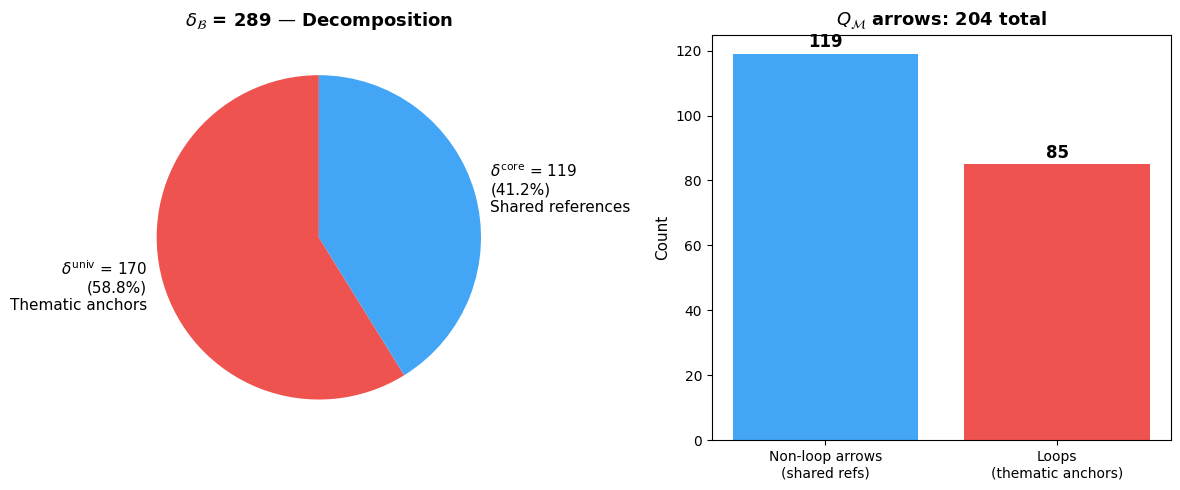

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart: δ decomposition
labels = [f'$\\delta^{{\\mathrm{{univ}}}}$ = {delta_univ_c}\n({100*delta_univ_c/delta_c:.1f}%)\nThematic anchors',
          f'$\\delta^{{\\mathrm{{core}}}}$ = {delta_core_c}\n({100*delta_core_c/delta_c:.1f}%)\nShared references']
axes[0].pie([delta_univ_c, delta_core_c], labels=labels,
            colors=['#EF5350', '#42A5F5'], autopct='', startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title(f'$\\delta_{{\\mathcal{{B}}}}$ = {delta_c} — Decomposition', fontsize=13, fontweight='bold')

# Bar chart: arrows
non_loop_arrows = S_c - len(C_M_c)
axes[1].bar(['Non-loop arrows\n(shared refs)', 'Loops\n(thematic anchors)'],
            [non_loop_arrows, len(C_M_c)],
            color=['#42A5F5', '#EF5350'])
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title(f'$Q_{{\\mathcal{{M}}}}$ arrows: {S_c} total', fontsize=13, fontweight='bold')
for i, v in enumerate([non_loop_arrows, len(C_M_c)]):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Top references by valency

In [21]:
# Shared references: val ≥ 2 (non-anchors)
non_trunc = [(v, bc_canadas.valency(v)) for v in bc_canadas.Gamma0 if bc_canadas.valency(v) >= 2]
non_trunc.sort(key=lambda x: -x[1])

top_df = pd.DataFrame([
    {
        'Reference': v,
        'val(m)': bc_canadas.valency(v),
        'val·(val-1)': bc_canadas.valency(v) * (bc_canadas.valency(v) - 1),
        'ω(m)': bc_canadas.valency(v),  # μ=1 for shared refs
        'p_m': bc_canadas.valency(v) / delta_c,
    }
    for v, val in non_trunc
])

print(f"All {len(non_trunc)} shared references (val ≥ 2, μ = 1):")
print(top_df.to_string(index=False))
print(f"\nΣ val·(val-1) for shared = {top_df['val·(val-1)'].sum()}")
print(f"{len(C_M_c)} thematic anchors contribute {len(C_M_c)}·1 = {len(C_M_c)}")
print(f"dim = 2·{h_c} + {len(C_M_c)} + {top_df['val·(val-1)'].sum()} = {2*h_c + len(C_M_c) + top_df['val·(val-1)'].sum()}")

All 19 shared references (val ≥ 2, μ = 1):
                             Reference  val(m)  val·(val-1)  ω(m)      p_m
                    green_schroll_2011      17          272    17 0.058824
                         espinosa_2020      15          210    15 0.051903
                   canadas2021mcnugget      14          182    14 0.048443
                          schroll_2018      14          182    14 0.048443
                           sierra_2018      12          132    12 0.041522
                            assem_2006      10           90    10 0.034602
                 agudelo_2021_01brauer       5           20     5 0.017301
                 canadas2023yangbaxter       4           12     4 0.013841
          canadas_angarita_2021_crypto       4           12     4 0.013841
                          stanley_1999       4           12     4 0.013841
                          andrews_2010       3            6     3 0.010381
                           ringel_2016       3           

### The Matthew effect and entropy

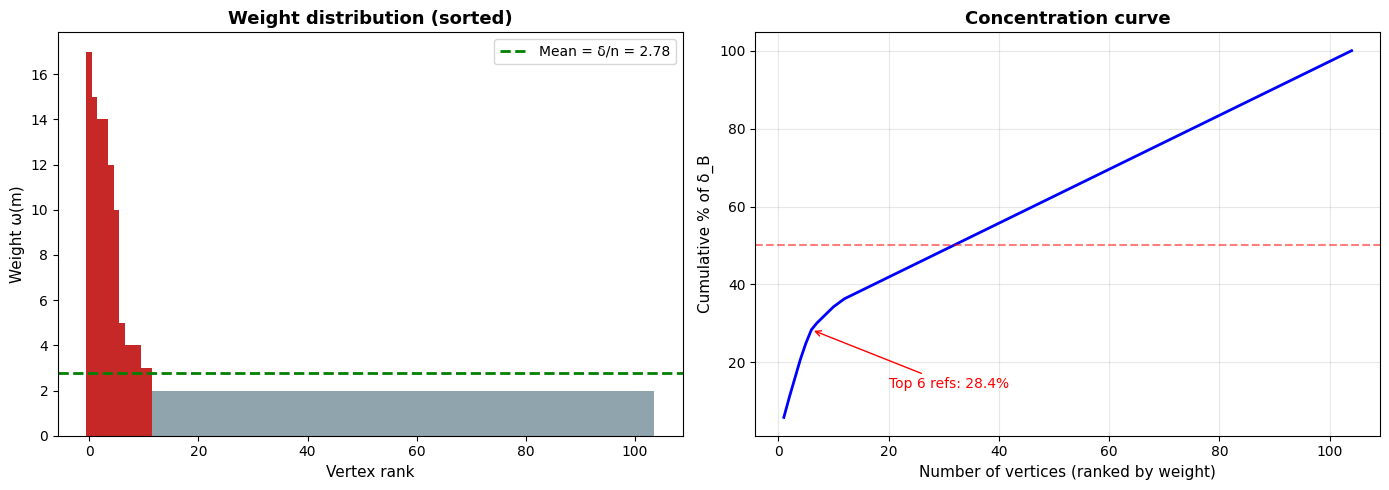


Matthew effect: top 6 shared refs (5.8% of Γ₀) carry 28.4% of δ_B
But ρ(B) = 0.9412 → moderately uniform
μ acts as diversity regularizer: 85 thematic anchors each carry ω=2,
preventing collapse onto the few highly-cited shared references.


In [22]:
# Weight distribution
weights = sorted(
    [(v, bc_canadas.mu(v) * bc_canadas.valency(v)) for v in bc_canadas.Gamma0],
    key=lambda x: -x[1]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weight distribution (sorted)
w_values = [w for _, w in weights]
colors = ['#C62828' if w > 2 else '#90A4AE' for w in w_values]
axes[0].bar(range(len(w_values)), w_values, color=colors, width=1.0)
axes[0].set_xlabel('Vertex rank', fontsize=11)
axes[0].set_ylabel('Weight ω(m)', fontsize=11)
axes[0].set_title('Weight distribution (sorted)', fontsize=13, fontweight='bold')
axes[0].axhline(y=delta_c/n_c, color='green', linestyle='--', linewidth=2,
                label=f'Mean = δ/n = {delta_c/n_c:.2f}')
axes[0].legend(fontsize=10)

# Cumulative weight share
cumulative = np.cumsum(w_values) / delta_c * 100
axes[1].plot(range(1, len(cumulative)+1), cumulative, 'b-', linewidth=2)
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Number of vertices (ranked by weight)', fontsize=11)
axes[1].set_ylabel('Cumulative % of δ_B', fontsize=11)
axes[1].set_title('Concentration curve', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Annotate
top6_share = sum(w for _, w in weights[:6]) / delta_c * 100
axes[1].annotate(f'Top 6 refs: {top6_share:.1f}%',
                 xy=(6, cumulative[5]), xytext=(20, cumulative[5]-15),
                 fontsize=10, arrowprops=dict(arrowstyle='->', color='red'),
                 color='red')

plt.tight_layout()
plt.show()

print(f"\nMatthew effect: top 6 shared refs ({6/n_c*100:.1f}% of Γ₀) carry {top6_share:.1f}% of δ_B")
print(f"But ρ(B) = {rho_c:.4f} → moderately uniform")
print(f"μ acts as diversity regularizer: {len(C_M_c)} thematic anchors each carry ω=2,")
print(f"preventing collapse onto the few highly-cited shared references.")

### The backbone: successor sequence of Green & Schroll (val = 17)

The reference with maximum valency traverses **all 17 articles** in chronological order, forming a Hamiltonian cycle in $Q_{\mathcal{M}}$.

/tmp/ipykernel_108851/1103043942.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(len(all_refs), 1))


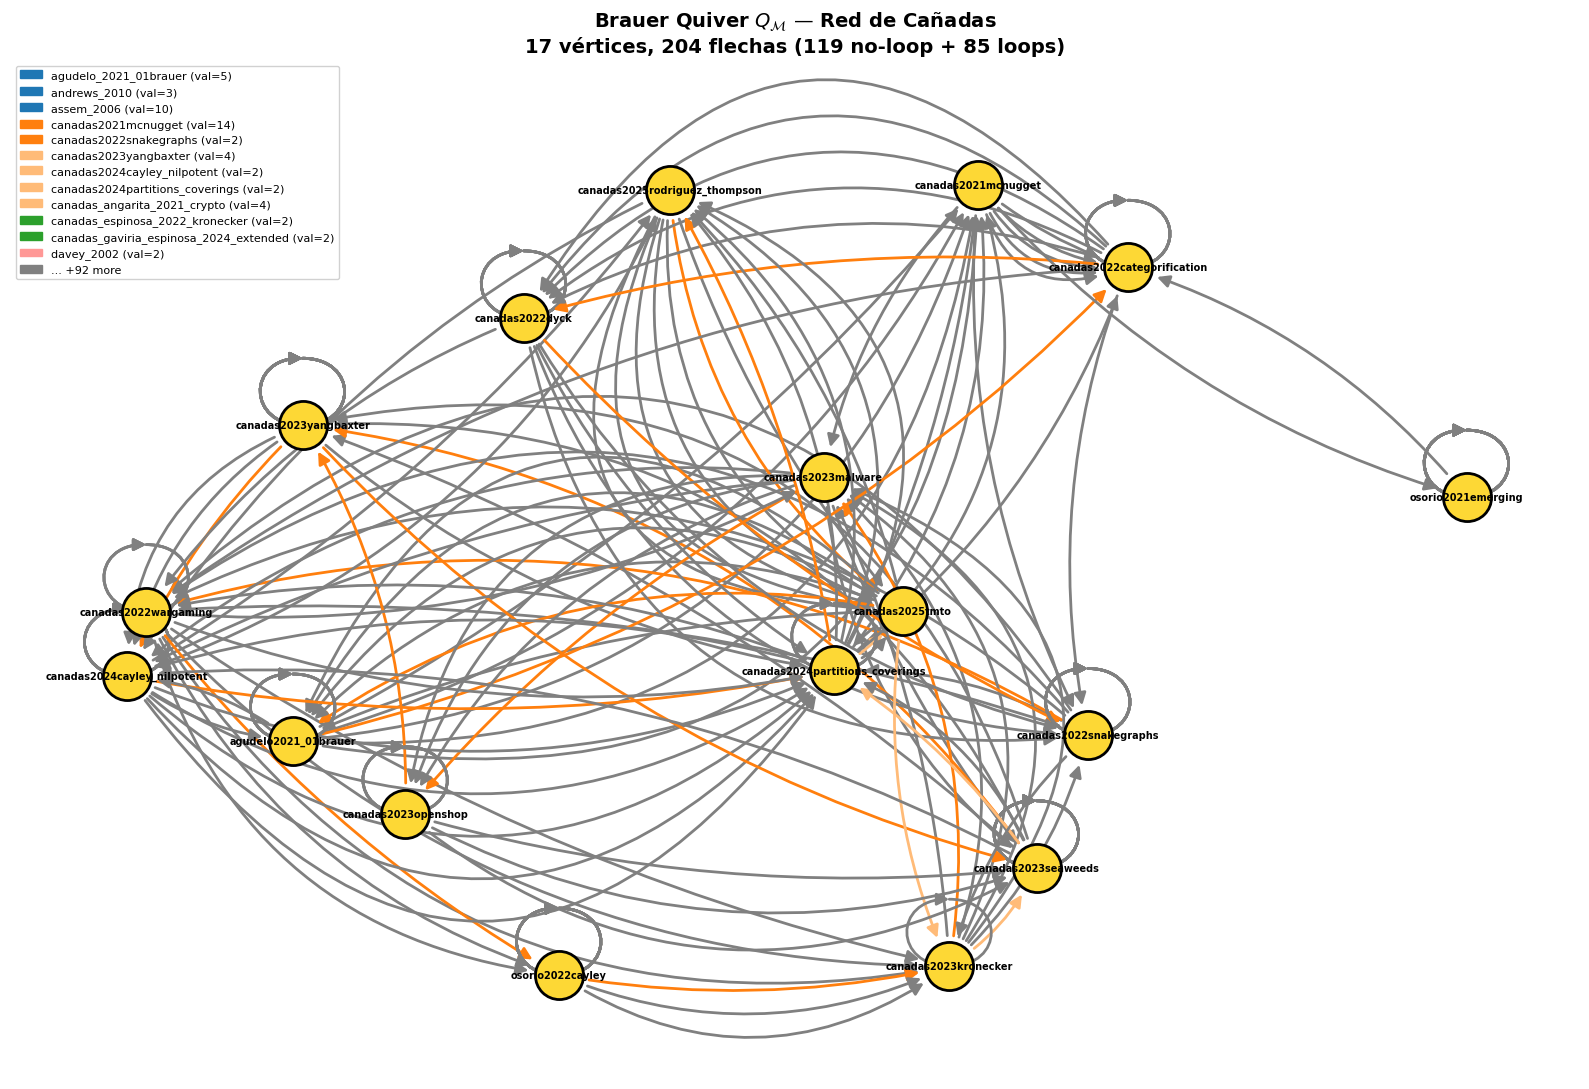

Nota: se omiten etiquetas individuales por claridad (204 flechas).
Use el explorador interactivo de la sección siguiente para inspeccionar sub-redes.


In [23]:
Q_canadas = bc_canadas.brauer_quiver()

draw_brauer_quiver(
    bc_canadas, figsize=(16, 11),
    title=f'Brauer Quiver $Q_{{\\mathcal{{M}}}}$ — Red de Cañadas\n'
          f'{Q_canadas.n_vertices} vértices, {Q_canadas.n_arrows} flechas '
          f'({Q_canadas.n_arrows - bc_canadas.n_loops()} no-loop + {bc_canadas.n_loops()} loops)',
    show_edge_labels=False,  # too many edges for the full network
    node_size=1200, font_size=7,
)
plt.show()

print(f"Nota: se omiten etiquetas individuales por claridad ({Q_canadas.n_arrows} flechas).")
print(f"Use el explorador interactivo de la sección siguiente para inspeccionar sub-redes.")

### Explorador interactivo: inspeccionar la red de Cañadas

Seleccione una referencia para ver su secuencia de sucesores, las flechas que genera, y su contribución a los invariantes. También puede filtrar por valencia mínima para explorar sub-redes.

In [24]:
# ══════════════════════════════════════════════════════════════════
# INTERACTIVE: Explore the Cañadas network reference by reference
# ══════════════════════════════════════════════════════════════════

# Sort references by valency (descending)
_sorted_refs = sorted(bc_canadas.Gamma0, key=lambda v: -bc_canadas.valency(v))
_ref_options = [f"{v}  (val={bc_canadas.valency(v)})" for v in _sorted_refs]

ref_dropdown = widgets.Dropdown(
    options=list(zip(_ref_options, _sorted_refs)),
    value=_sorted_refs[0],
    description='Referencia:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='500px'),
)

val_slider = widgets.IntSlider(
    value=2, min=1, max=17, step=1,
    description='Valencia mín. para sub-red:',
    style={'description_width': '200px'},
    layout=widgets.Layout(width='500px'),
)

explore_output = widgets.Output()

def explore_reference(change=None):
    explore_output.clear_output(wait=True)
    with explore_output:
        ref = ref_dropdown.value
        val = bc_canadas.valency(ref)
        mu = bc_canadas.mu(ref)
        omega = mu * val

        display(Markdown(f"## Referencia: `{ref}`"))

        # Basic info
        vdata = bc_canadas._vertex_data.get(ref, {})
        if vdata:
            title = vdata.get('title', '')
            year = vdata.get('year', '')
            if title:
                print(f"  Título: {title}")
            if year:
                print(f"  Año: {year}")

        print(f"\n  val({ref}) = {val}")
        print(f"  μ({ref}) = {mu}")
        print(f"  ω({ref}) = μ·val = {omega}")
        print(f"  p_{ref} = ω/δ_B = {omega}/{delta_c} = {omega/delta_c:.4f}")
        print(f"  Tipo: {'TRUNCADO (genera loop)' if bc_canadas.is_truncated(ref) else 'No truncado (genera flechas entre polígonos)'}")

        # Successor sequence
        seqs = bc_canadas.successor_sequences()
        seq = seqs[ref]
        print(f"\n  Secuencia de sucesores S_{ref} (longitud {len(seq)}):")
        for i, (poly, copy) in enumerate(seq):
            pdata = bc_canadas._polygon_data.get(poly, {})
            year = pdata.get('year', '?')
            title = pdata.get('title', poly)[:55]
            next_poly = seq[(i + 1) % len(seq)][0]
            is_loop = "↺ LOOP" if poly == next_poly else f"→ {next_poly}"
            print(f"    {i+1:2d}. [{year}] {title}  {is_loop}")

        # Incidence set
        inc = bc_canadas.incidence_set(ref)
        print(f"\n  Conjunto de incidencia I_{ref}: aparece en {len(inc)} polígono(s)")
        for pname, mult in inc:
            print(f"    {pname} (multiplicidad {mult})")

        # Sub-network visualization
        min_val = val_slider.value
        display(Markdown(f"### Sub-red: referencias con val ≥ {min_val}"))

        sub_refs = [v for v in bc_canadas.Gamma0 if bc_canadas.valency(v) >= min_val]
        # Build sub-configuration
        sub_polygons = {}
        for pname, pverts in bc_canadas.Gamma1.items():
            filtered = [v for v in pverts if v in set(sub_refs)]
            if len(filtered) >= 1:
                sub_polygons[pname] = filtered

        if sub_polygons and sub_refs:
            sub_verts = set()
            for vlist in sub_polygons.values():
                sub_verts.update(vlist)
            sub_verts = sorted(sub_verts)

            if len(sub_verts) >= 1 and len(sub_polygons) >= 1:
                try:
                    bc_sub = BrauerConfiguration(vertices=sub_verts, polygons=sub_polygons)
                    Q_sub = bc_sub.brauer_quiver()
                    print(f"  Sub-red: {bc_sub.n_vertices} refs, {bc_sub.n_polygons} artículos, "
                          f"{Q_sub.n_arrows} flechas, {bc_sub.n_loops()} loops")
                    print(f"  δ_B(sub) = {bc_sub.impact_factor()}, H(sub) = {bc_sub.entropy():.4f} bits")

                    draw_brauer_quiver(
                        bc_sub, figsize=(11, 7),
                        title=f'Sub-red: val ≥ {min_val} ({bc_sub.n_vertices} refs, {Q_sub.n_arrows} flechas)',
                        show_edge_labels=(Q_sub.n_arrows <= 40),
                        node_size=1800, font_size=9,
                    )
                    plt.show()
                except Exception as e:
                    print(f"  No se puede construir sub-red: {e}")
            else:
                print("  Sub-red vacía con estos parámetros.")
        else:
            print("  No hay polígonos con estas referencias.")

ref_dropdown.observe(explore_reference, names='value')
val_slider.observe(explore_reference, names='value')

display(widgets.VBox([ref_dropdown, val_slider]), explore_output)
explore_reference()  # initial render

Output()

## 10. Open Problems and Extensions <a id='10-open-problems'></a>

The paper identifies six open problems:

1. **Behavior under morphisms.** How do $\delta_{\mathcal{B}}$ and $H(\mathcal{B})$ transform under morphisms of Brauer configurations?

2. **Temporal evolution.** For a growing citation network, how do $\delta_{\mathcal{B}}(t)$ and $H(\mathcal{B})(t)$ evolve?

3. **Hochschild cohomology.** Is there a relationship between $H(\mathcal{B})$ and $HH^*(\Lambda_{\mathcal{M}})$?

4. **Product configurations.** Does $H(\mathcal{B})(\Gamma \otimes \Gamma') = H(\mathcal{B})(\Gamma) + H(\mathcal{B})(\Gamma')$?

5. **Large-scale networks.** Apply to Cora, cit-HepPh datasets (available in `aiq.datasets`).

6. **Optimal configurations.** For fixed $n$ and $h$, which configurations extremize $H(\mathcal{B})$?

### Quick exploration of Problem 5: applying to Cora

In [25]:
# This is a starting point for Open Problem 5.
# For a full Brauer analysis of Cora or cit-HepPh, one would need to:
# 1. Load the citation quiver
# 2. Convert it to a Brauer configuration (Γ₀ = cited papers, Γ₁ = citing papers)
# 3. Compute all invariants
#
# The AIQ framework provides the dynamic complement:

from aiq import AIQ
from aiq.datasets import example_5node_citation_quiver

Q5 = example_5node_citation_quiver()
aiq = AIQ(Q5, states=['S', 'R', 'O'], evolution_rule='SIR',
          beta=1.0, recovery_prob=0.3)
aiq.set_initial_config({'P1': 'R', 'P2': 'S', 'P3': 'S', 'P4': 'S', 'P5': 'S'})
aiq.run(10, seed=42)

print("AIQ dynamics (5-node citation quiver):")
print(aiq.orbit_counts_table())
print()
print("Connection: univalent vertices in Brauer ↔ topological traps in AIQ")
print(f"Topologically trapped: {aiq.topologically_trapped_vertices()}")

AIQ dynamics (5-node citation quiver):
    S  R  O
t          
0   4  1  0
1   2  2  1
2   0  4  1
3   0  3  2
4   0  1  4
5   0  1  4
6   0  0  5
7   0  0  5
8   0  0  5
9   0  0  5
10  0  0  5

Connection: univalent vertices in Brauer ↔ topological traps in AIQ
Topologically trapped: ['P1']


### Summary table: Static (Brauer) vs Dynamic (AIQ)

| Brauer invariant (static) | AIQ concept (dynamic) |
|---------------------------|----------------------|
| $\delta_{\mathcal{B}}$ (total weight) | Total influence mass in the network |
| $\delta_{\mathcal{B}}^{\text{core}} / \delta_{\mathcal{B}}$ | Fraction of influence carried by shared references |
| $H(\mathcal{B})$ (entropy) | Uniformity of influence propagation |
| $\rho(\mathcal{B})$ (entropy ratio) | Normalized concentration index |
| $C_{\mathcal{M}}$ (univalent vertices) | Topological traps (isolated influence sources) |
| $\dim_k \Lambda_{\mathcal{M}}$ | Complexity of the walk structure |

---

**Package:** [`pip install aiq-quivers`](https://pypi.org/project/aiq-quivers/)  
**Repository:** [github.com/Izainea/aiq-quivers](https://github.com/Izainea/aiq-quivers)  
**Paper:** Zainea Maya & Moreno Cañadas, *"Brauer Impact Factor and Entropy of Brauer Configuration Algebras"*, Universidad Nacional de Colombia, 2025.